# Predictive Analysis : Prediksi Penyakit Kanker Payudara
> *oleh : ANDIKA BINTANG NURSALIH*
### Project Submission 1 Machine Learning Terapan
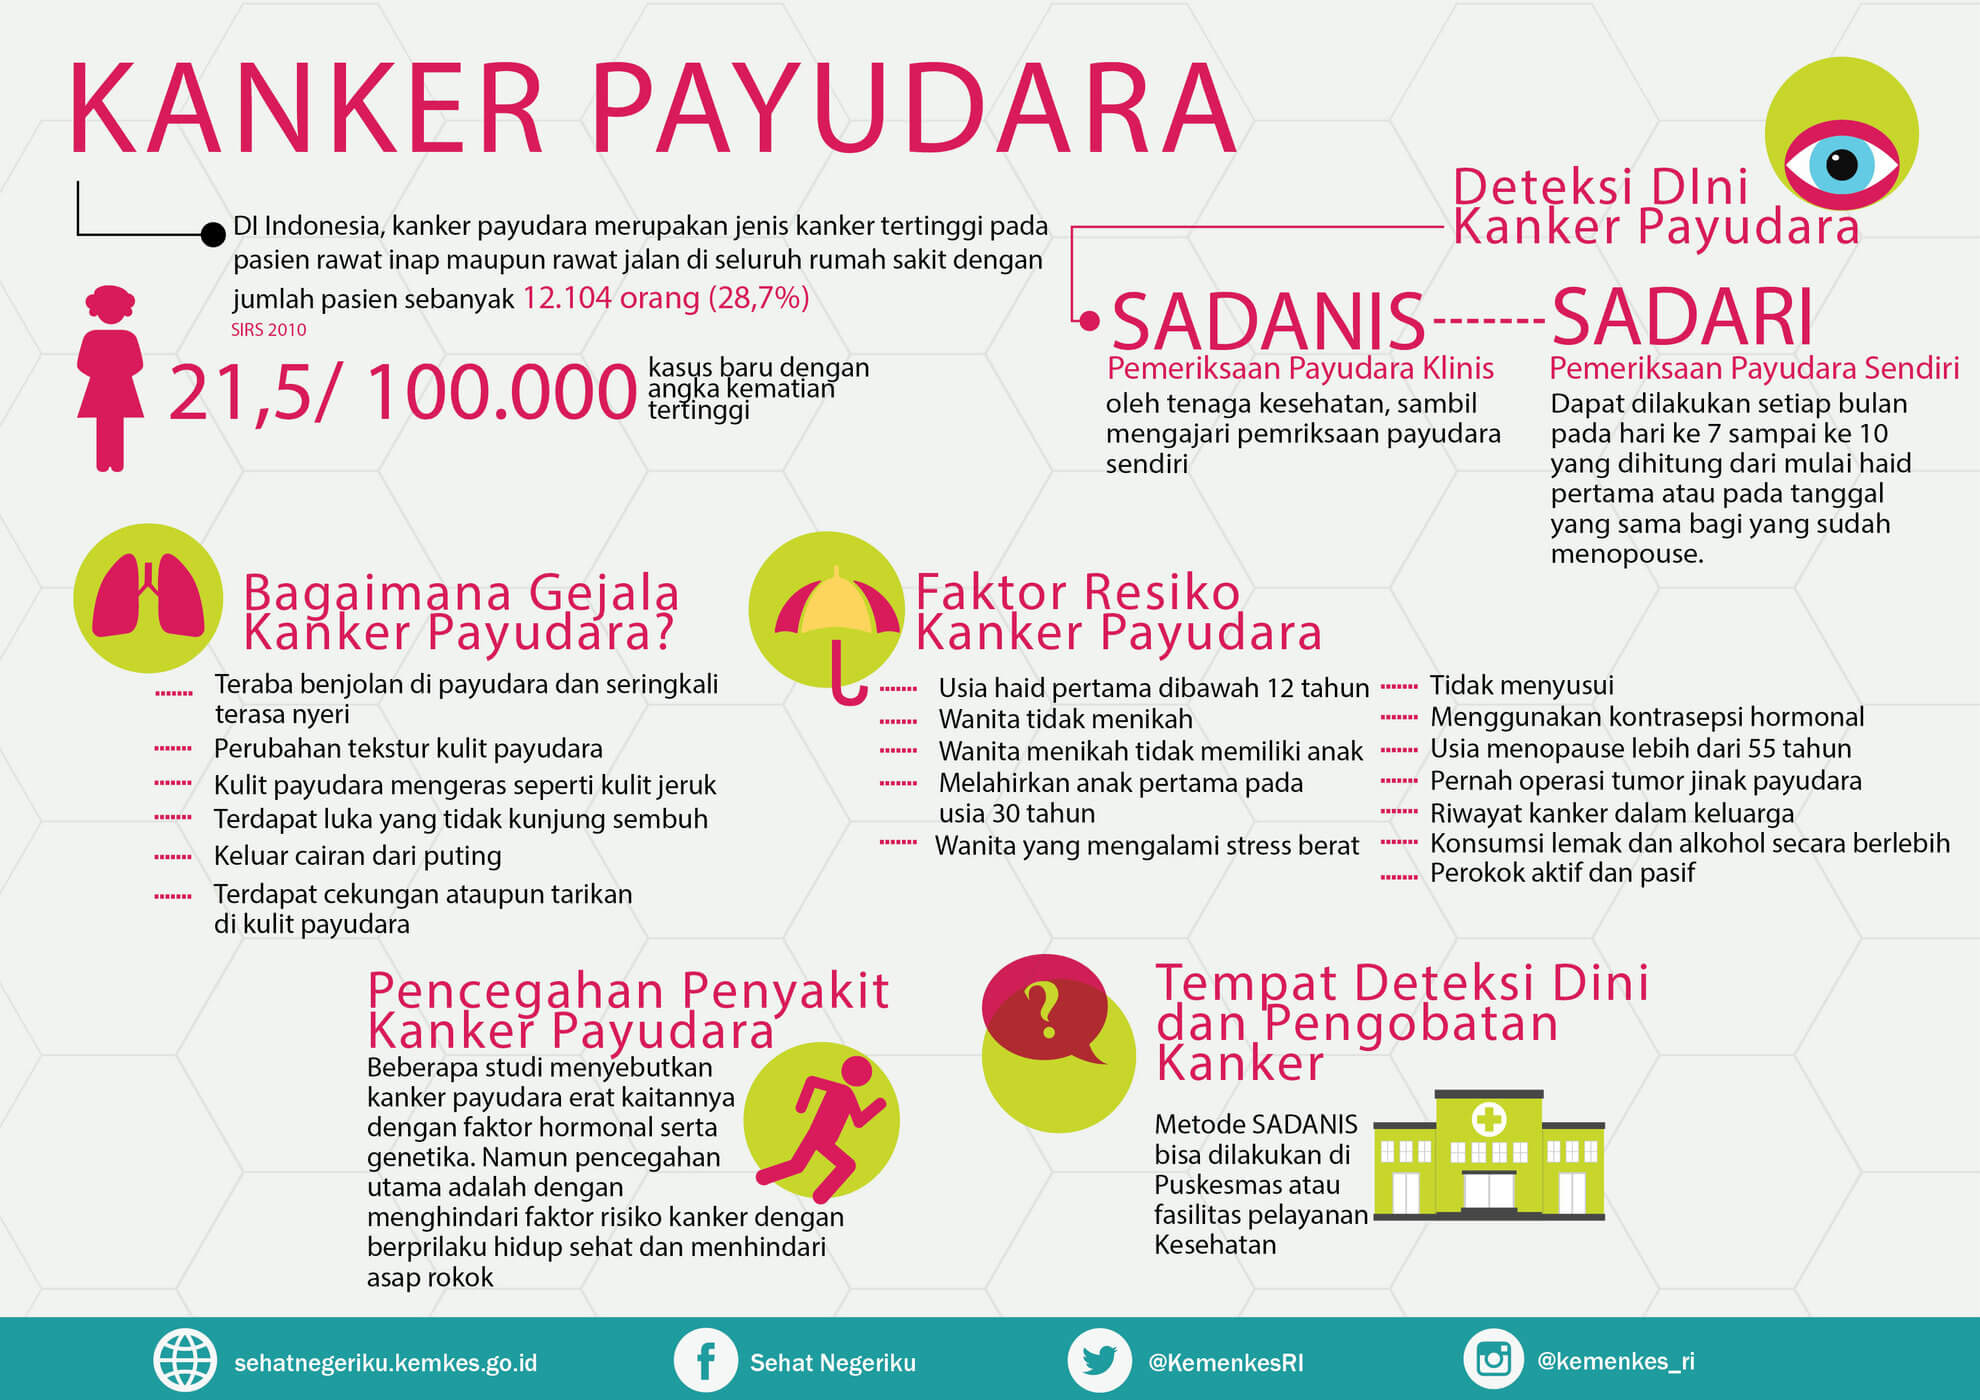

[link Project : Sumber Kaggle](https://www.kaggle.com/datasets/yasserh/breast-cancer-dataset)

# Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


# Import library yang diperlukan

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Membaca dataset dari drive

In [6]:
data_path = '/content/drive/MyDrive/Dataset/breast-cancer.csv'
dataframe = pd.read_csv(data_path)
print(dataframe.head())

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  perimeter_worst  area_wor

In [7]:
print(dataframe.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

# Cek data yang hilang di tiap kolom

In [8]:
print("Jumlah nilai kosong tiap kolom:\n", dataframe.isnull().sum())

Jumlah nilai kosong tiap kolom:
 id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


# Menampilkan ukuran dataset


In [9]:
print("Ukuran dataset:", dataframe.shape)

Ukuran dataset: (569, 32)


# Menghapus kolom yang tidak diperlukan

In [10]:
dataframe.drop('id', axis=1, inplace=True)

# Statistik deskriptif dataset

In [11]:
print(dataframe.describe())

       radius_mean  texture_mean  perimeter_mean    area_mean  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000             0.000000   
25%      

# Mendefinisikan fitur kategorikal dan numerik

In [12]:
kolom_kategori = ['diagnosis']
kolom_numerik = [
    'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
    'smoothness_mean', 'compactness_mean', 'concavity_mean',
    'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
    'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
    'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
    'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst',
    'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst',
    'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst'
]

# Analisis distribusi variabel kategori 'diagnosis'

In [13]:
diagnosis = kolom_kategori[0]
jumlah_diagnosis = dataframe[diagnosis].value_counts()
persentase_diagnosis = 100 * dataframe[diagnosis].value_counts(normalize=True)
rekap_diagnosis = pd.DataFrame({'Jumlah Sampel': jumlah_diagnosis,
                                'Persentase': persentase_diagnosis.round(1)})
print(rekap_diagnosis)

           Jumlah Sampel  Persentase
diagnosis                           
B                    357        62.7
M                    212        37.3


# Plot distribusi diagnosis

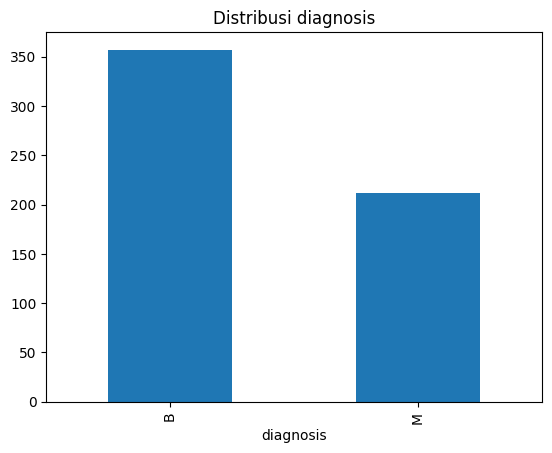

In [14]:
jumlah_diagnosis.plot(kind='bar', title=f"Distribusi {diagnosis}")
plt.show()

# Menampilkan histogram untuk semua fitur

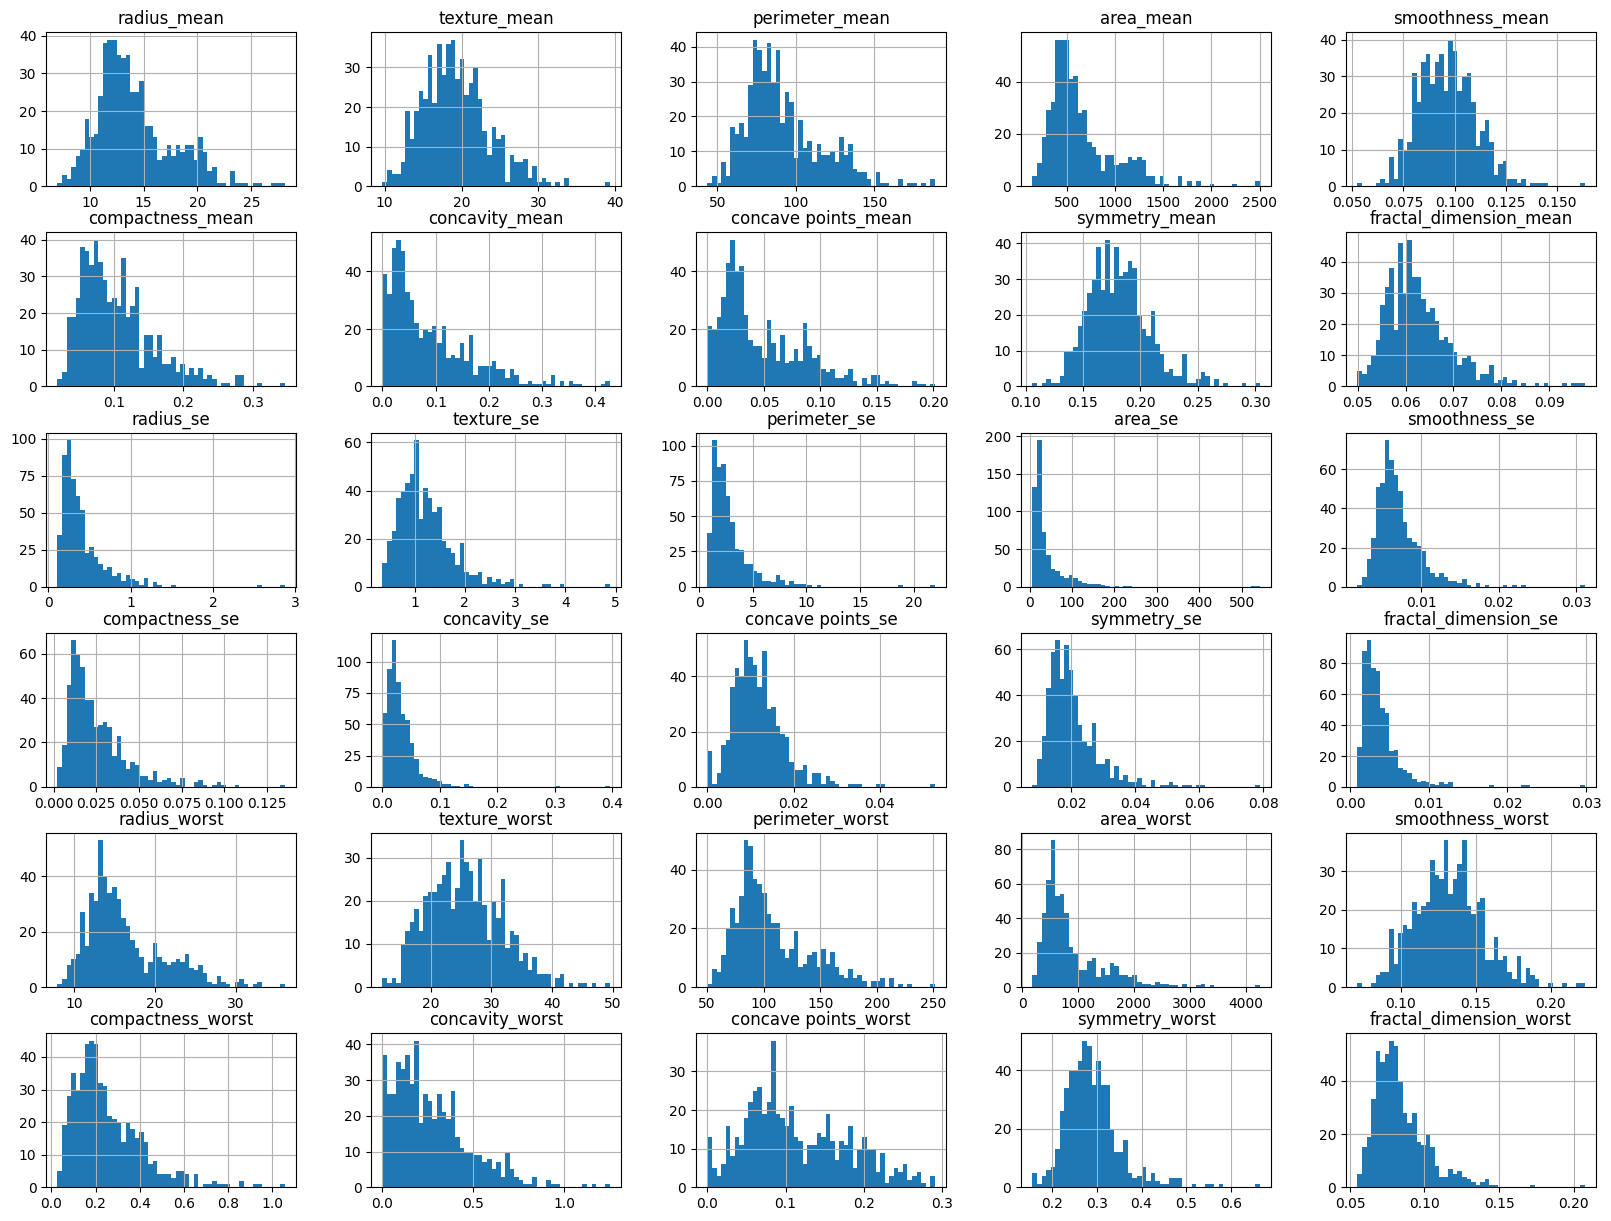

In [15]:
dataframe.hist(bins=50, figsize=(20,15))
plt.show()

# Visualisasi matriks korelasi fitur numerik

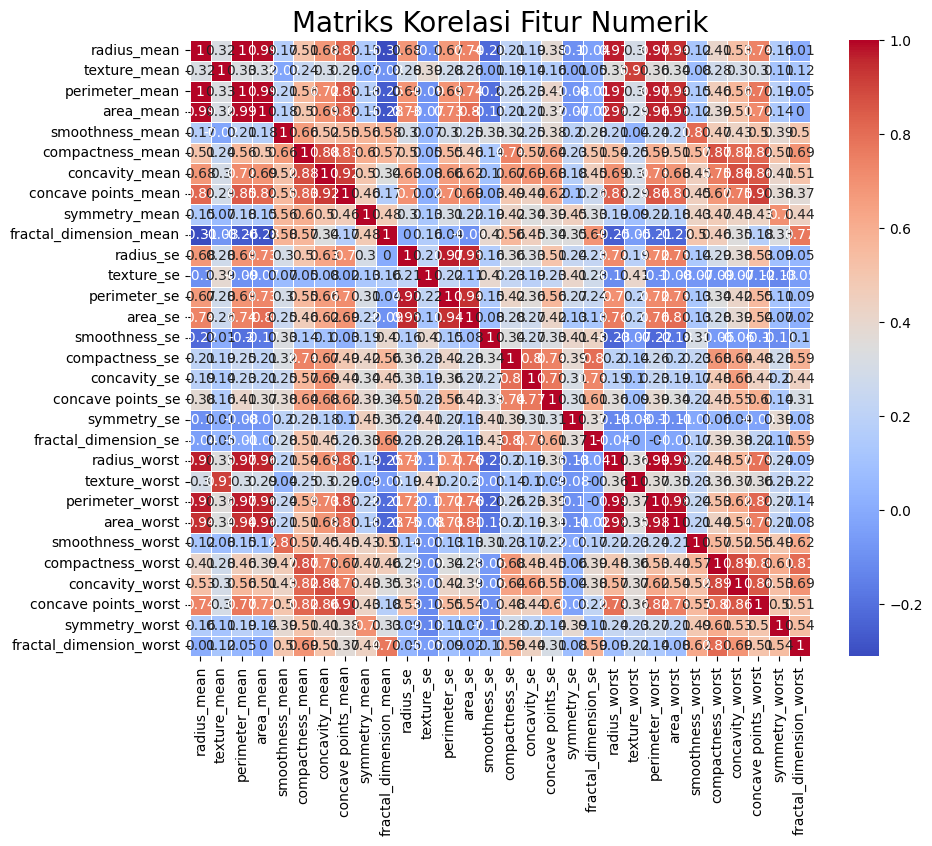

In [18]:
numeric_dataframe = dataframe.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))
matriks_korelasi = numeric_dataframe.corr().round(2)
sns.heatmap(matriks_korelasi, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Matriks Korelasi Fitur Numerik", fontsize=20)
plt.show()


# Melihat nilai unik dari diagnosis

In [19]:
print("Nilai unik diagnosis:", dataframe['diagnosis'].unique())

Nilai unik diagnosis: ['M' 'B']


# Konversi label diagnosis ke angka: 'B' menjadi 0 dan 'M' menjadi 1

In [20]:
label_mapping = {'B': 0, 'M': 1}
dataframe['diagnosis'] = dataframe['diagnosis'].map(label_mapping)
print(dataframe['diagnosis'].value_counts())

diagnosis
0    357
1    212
Name: count, dtype: int64



# Memisahkan fitur (X) dan target (y)

In [21]:
X = dataframe.drop('diagnosis', axis=1)
y = dataframe['diagnosis']

# Membagi data menjadi data latih dan data uji

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)
print(f"Total sampel: {len(X)}")
print(f"Sampel data latih: {len(X_train)}")
print(f"Sampel data uji: {len(X_test)}")

Total sampel: 569
Sampel data latih: 455
Sampel data uji: 114


# Standarisasi fitur

In [23]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Placeholder untuk menyimpan analisis model (MSE)

In [24]:
hasil_model = pd.DataFrame(index=['train_mse', 'test_mse'], columns=['RandomForest', 'KNN', 'Boosting'])

# 1. Model Random Forest

In [25]:
rf = RandomForestClassifier()
rf.fit(X_train_scaled, y_train)
prediksi_rf = rf.predict(X_test_scaled)
print("Akurasi Random Forest:", accuracy_score(y_test, prediksi_rf))
laporan_rf = classification_report(y_test, prediksi_rf, output_dict=True)
print(pd.DataFrame(laporan_rf).transpose())

Akurasi Random Forest: 0.9736842105263158
              precision    recall  f1-score     support
0              0.956522  1.000000  0.977778   66.000000
1              1.000000  0.937500  0.967742   48.000000
accuracy       0.973684  0.973684  0.973684    0.973684
macro avg      0.978261  0.968750  0.972760  114.000000
weighted avg   0.974828  0.973684  0.973552  114.000000


# 2. Model KNN

In [26]:
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)
prediksi_knn = knn.predict(X_test_scaled)
print("Akurasi KNN:", accuracy_score(y_test, prediksi_knn))
laporan_knn = classification_report(y_test, prediksi_knn, output_dict=True)
print(pd.DataFrame(laporan_knn).transpose())

Akurasi KNN: 0.9649122807017544
              precision    recall  f1-score     support
0              0.942857  1.000000  0.970588   66.000000
1              1.000000  0.916667  0.956522   48.000000
accuracy       0.964912  0.964912  0.964912    0.964912
macro avg      0.971429  0.958333  0.963555  114.000000
weighted avg   0.966917  0.964912  0.964666  114.000000


# 3. Model Boosting

In [27]:
from sklearn.ensemble import AdaBoostClassifier

boost = AdaBoostClassifier(n_estimators=50, random_state=5)
boost.fit(X_train_scaled, y_train)
boost_pred = boost.predict(X_test_scaled)

print("Akurasi Boosting:", accuracy_score(y_test, boost_pred))
laporan_boost = classification_report(y_test, boost_pred, output_dict=True)
print(pd.DataFrame(laporan_boost).transpose())

Akurasi Boosting: 0.9736842105263158
              precision    recall  f1-score     support
0              0.956522  1.000000  0.977778   66.000000
1              1.000000  0.937500  0.967742   48.000000
accuracy       0.973684  0.973684  0.973684    0.973684
macro avg      0.978261  0.968750  0.972760  114.000000
weighted avg   0.974828  0.973684  0.973552  114.000000


# Update tabel komparasi metrik untuk menyertakan Boosting

In [28]:
komparasi_metrik = pd.DataFrame({
    'accuracy': [laporan_rf['accuracy'], laporan_knn['accuracy'], laporan_boost['accuracy']],
    'f1-score_0': [laporan_rf['0']['f1-score'], laporan_knn['0']['f1-score'], laporan_boost['0']['f1-score']],
    'precision_0': [laporan_rf['0']['precision'], laporan_knn['0']['precision'], laporan_boost['0']['precision']],
    'recall_0': [laporan_rf['0']['recall'], laporan_knn['0']['recall'], laporan_boost['0']['recall']],
    'f1-score_1': [laporan_rf['1']['f1-score'], laporan_knn['1']['f1-score'], laporan_boost['1']['f1-score']],
    'precision_1': [laporan_rf['1']['precision'], laporan_knn['1']['precision'], laporan_boost['1']['precision']],
    'recall_1': [laporan_rf['1']['recall'], laporan_knn['1']['recall'], laporan_boost['1']['recall']]
}, index=['RandomForest', 'KNN', 'Boosting'])

header_multi = pd.MultiIndex.from_tuples([
    ('', 'accuracy'),
    ('0', 'f1-score'),
    ('0', 'precision'),
    ('0', 'recall'),
    ('1', 'f1-score'),
    ('1', 'precision'),
    ('1', 'recall')
])
komparasi_metrik.columns = header_multi
print(komparasi_metrik)

                               0                          1            \
              accuracy  f1-score precision recall  f1-score precision   
RandomForest  0.973684  0.977778  0.956522    1.0  0.967742       1.0   
KNN           0.964912  0.970588  0.942857    1.0  0.956522       1.0   
Boosting      0.973684  0.977778  0.956522    1.0  0.967742       1.0   

                        
                recall  
RandomForest  0.937500  
KNN           0.916667  
Boosting      0.937500  


# Visualisasi Confusion Matrix untuk Random Forest

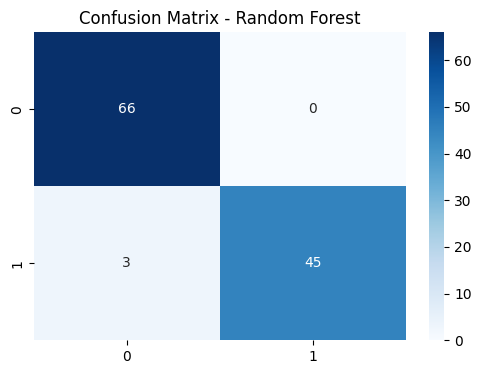

In [30]:
cm_rf = confusion_matrix(y_test, prediksi_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.show()

# Visualisasi Confusion Matrix untuk KNN

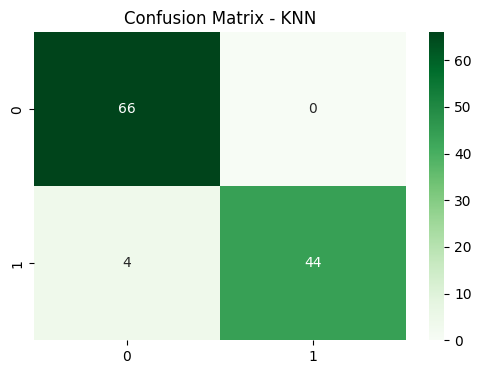

In [31]:
cm_knn = confusion_matrix(y_test, prediksi_knn)
plt.figure(figsize=(6,4))
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - KNN")
plt.show()

# Visualisasi Confusion Matrix untuk Boosting

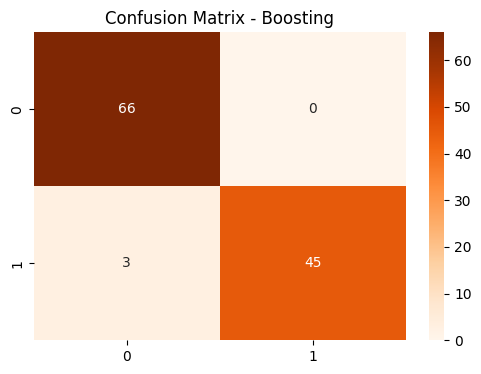

In [29]:
cm_boost = confusion_matrix(y_test, boost_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm_boost, annot=True, fmt="d", cmap="Oranges")
plt.title("Confusion Matrix - Boosting")
plt.show()